In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import data
df = pd.read_csv('O_ALL_10_YEARS.csv').drop(columns=['Unnamed: 0'])

/var/folders/46/mjvmwj6x7n5_cdghvmx10bkm0000gn/T/ipykernel_59976/2404703018.py:2: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('O_ALL_10_YEARS.csv')


## Medicare Participationg Indicator

In [14]:
# check provider medicare participation indicator
df['Rndrng_Prvdr_Mdcr_Prtcptg_Ind'].value_counts()

Rndrng_Prvdr_Mdcr_Prtcptg_Ind
Y    12221979
N       10215
Name: count, dtype: int64

most providers in this dataset participate in medicare

In [15]:
# check payment/charge ratio for participation = Y vs N
mask = df['Rndrng_Prvdr_Mdcr_Prtcptg_Ind']=='N'
df_Non_Prt = df[mask]
df_Prt = df[~mask]
print('payment/charge ratio for Y = ', sum(df_Prt['Tot_Mdcr_Pymt_Amt'])/sum(df_Prt['Tot_Sbmtd_Chrg']))
print('payment/charge ratio for N = ', sum(df_Non_Prt['Tot_Mdcr_Pymt_Amt'])/sum(df_Non_Prt['Tot_Sbmtd_Chrg']))
print('payment/charge ratio for ALL = ', sum(df['Tot_Mdcr_Pymt_Amt'])/sum(df['Tot_Sbmtd_Chrg']))

payment/charge ratio for Y =  0.2582178764107477
payment/charge ratio for N =  0.5686283198718807
payment/charge ratio for ALL =  0.25822978077517117


maybe we should keep the indicator column

## Histrogram of log(total_payment)

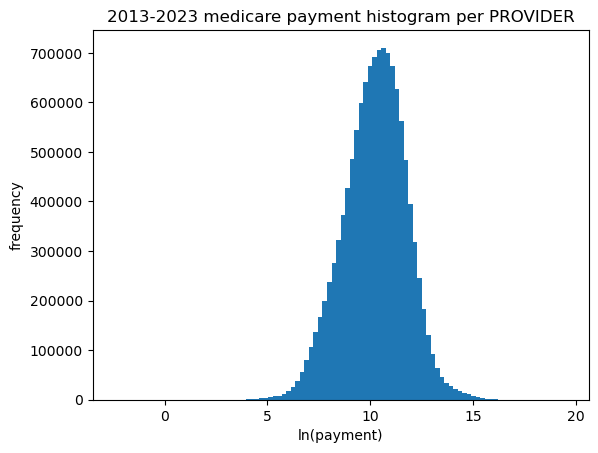

In [18]:
# histogram for total_medicare_payment_amount in 2013
if df['Tot_Mdcr_Pymt_Amt'].min() <= 0:
    m = sorted(df['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x>0 else 0).unique())[1]

M_payment = df['Tot_Mdcr_Pymt_Amt'].apply(lambda x: x if x!=0 else m) # turn all 0 payments to the minimum positive value

plt.hist(np.log(M_payment),bins=100)
plt.title('2013-2023 medicare payment histogram per PROVIDER')
plt.xlabel('ln(payment)')
plt.ylabel('frequency')
plt.show()

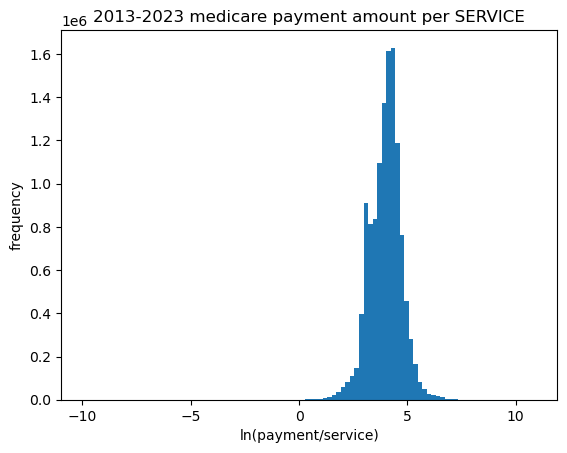

In [19]:
# histogram for medicare_payment per service
if df['Tot_Mdcr_Pymt_Amt'].min() <= 0:
    m = sorted(df['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x>0 else 0).unique())[1]
    
if df['Tot_Srvcs'].min() <= 0:
    n = sorted(df['Tot_Srvcs'].apply(lambda x:x if x>0 else 0).unique())[1]

Num_service = df['Tot_Srvcs'].apply(lambda x: x if x!=0 else n) # turn all 0 service to the minimum positive value
M_payment = df['Tot_Mdcr_Pymt_Amt'].apply(lambda x: x if x!=0 else m) # turn all 0 payments to the minimum positive value

plt.hist(np.log(M_payment/Num_service),bins=100)
plt.title('2013-2023 medicare payment amount per SERVICE')
plt.xlabel('ln(payment/service)')
plt.ylabel('frequency')
plt.show()

## Missing data

In [54]:
sum(df['Rndrng_Prvdr_State_Abrvtn'].isna()) # nice, no missing data in state

0

In [22]:
df.isna().sum(axis=0) # Count NaNs per column

Unnamed: 0                               0
Rndrng_NPI                               0
Rndrng_Prvdr_Last_Org_Name             145
Rndrng_Prvdr_First_Name             680168
Rndrng_Prvdr_MI                    4110962
                                    ...   
Bene_CC_PH_IschemicHeart_V2_Pct    5606818
Bene_CC_PH_Osteoporosis_V2_Pct     6521829
Bene_CC_PH_Parkinson_V2_Pct        8969585
Bene_CC_PH_Arthritis_V2_Pct        4786034
Bene_CC_PH_Stroke_TIA_V2_Pct       7160425
Length: 83, dtype: int64

### Drug and Med

In [26]:
# investigate non-demographic columns
col_keep_1 = ['Rndrng_NPI',
            'Rndrng_Prvdr_Ent_Cd',
            'Rndrng_Prvdr_State_Abrvtn',
            'Rndrng_Prvdr_Type',
            'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
            'Tot_HCPCS_Cds',
            'Tot_Benes',
            'Tot_Srvcs',
            'Tot_Sbmtd_Chrg',
            'Tot_Mdcr_Alowd_Amt',
            'Tot_Mdcr_Pymt_Amt',
            'Tot_Mdcr_Stdzd_Amt',
            'Drug_Sprsn_Ind',
            'Drug_Tot_HCPCS_Cds',
            'Drug_Tot_Benes',
            'Drug_Tot_Srvcs',
            'Drug_Sbmtd_Chrg',
            'Drug_Mdcr_Alowd_Amt',
            'Drug_Mdcr_Pymt_Amt',
            'Drug_Mdcr_Stdzd_Amt',
            'Med_Sprsn_Ind',
            'Drug_Tot_HCPCS_Cds',
            'Med_Tot_Benes',
            'Med_Tot_Srvcs',
            'Med_Sbmtd_Chrg',
            'Med_Mdcr_Alowd_Amt',
            'Med_Mdcr_Pymt_Amt',
            'Med_Mdcr_Stdzd_Amt',
            'Bene_Avg_Age',
            'Bene_Avg_Risk_Scre']
df_non_demo = df[col_keep_1].copy()

In [ ]:
# nan values check
nan_count = df_non_demo.isna().sum(axis=1) # Count NaNs per row
nan_count.value_counts()

2     10897678
14     1334516
Name: count, dtype: int64

In [31]:
sum(nan_count.value_counts())==df_non_demo.shape[0]

True

Either missing 2 columns or missing 14 columns, and they are complementary to each other.

In [ ]:
nan_cols_per_row = pd.DataFrame({'missing_columns':df_non_demo.isna().apply(lambda r: r.index[r].tolist(), axis=1)}).astype(str)
missing_cols = nan_cols_per_row.groupby('missing_columns').size().rename('missing_num_rows').reset_index()
missing_cols

,missing_columns,missing_num_rows
0,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']",10897678
1,"['Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug...",1334516


It looks like if the indicator columns got flagged (non-missing), then all med and drug related columns will be missing.
The drug and med indicators are always being flagged simultaneously.

## Some plots by year

In [43]:
def plt_total_col_by_year(df,col):
    result_col = df.groupby('year')[col].sum()
    plt.figure(figsize=(8,5))
    plt.plot(result_col.index, result_col.values, marker="o", label=f"{col}")
    plt.title(f"National {col} Spending")
    plt.xlabel("Year")
    plt.ylabel("Total Spending")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return 


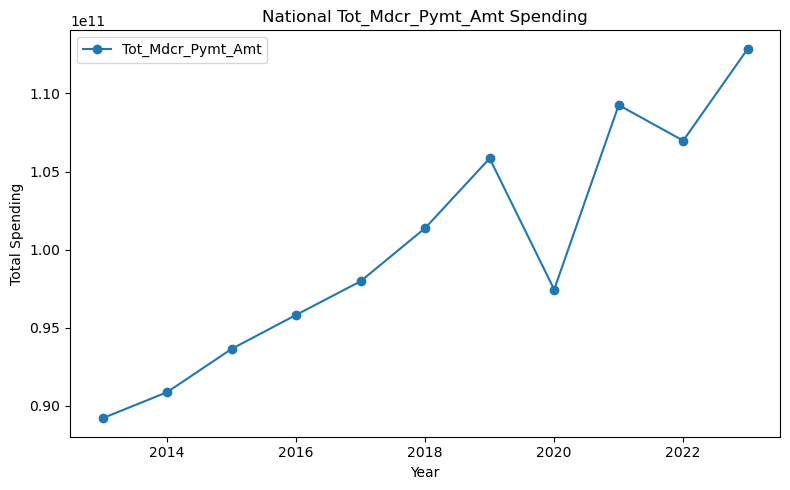

In [ ]:
# total medicare payment plot
plt_total_col_by_year(df,'Tot_Mdcr_Pymt_Amt')

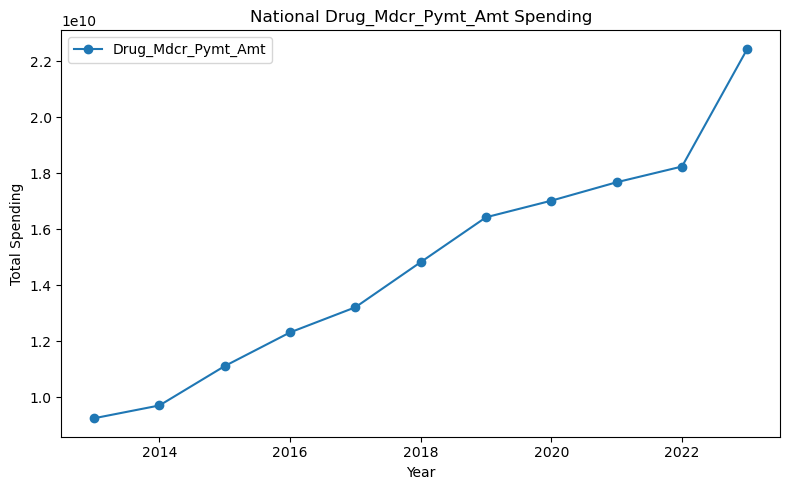

In [45]:
# total medicare drug payment plot
plt_total_col_by_year(df,'Drug_Mdcr_Pymt_Amt')

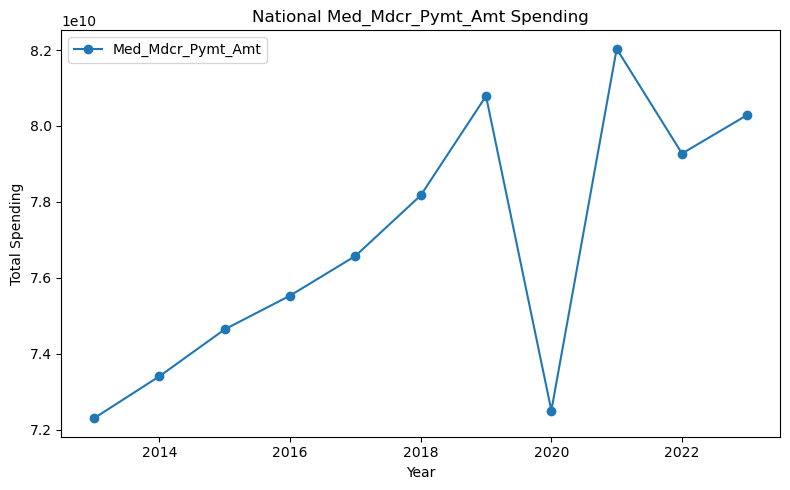

In [46]:
# total medicare med payment plot
plt_total_col_by_year(df,'Med_Mdcr_Pymt_Amt')

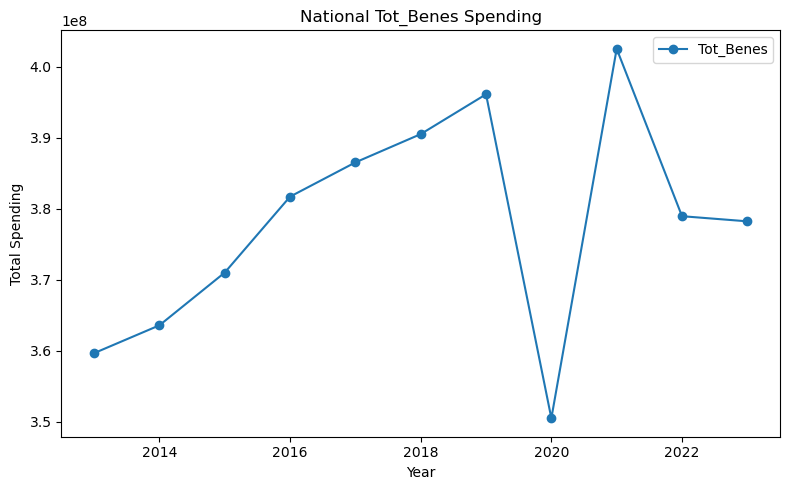

In [50]:
# Total number of beneficiaries plot
plt_total_col_by_year(df,'Tot_Benes')

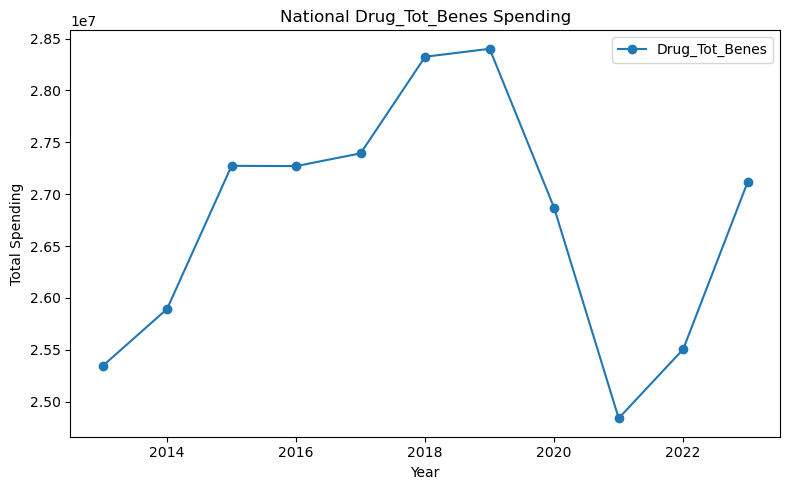

In [ ]:
# Total number of drug beneficiaries plot
plt_total_col_by_year(df,'Drug_Tot_Benes')

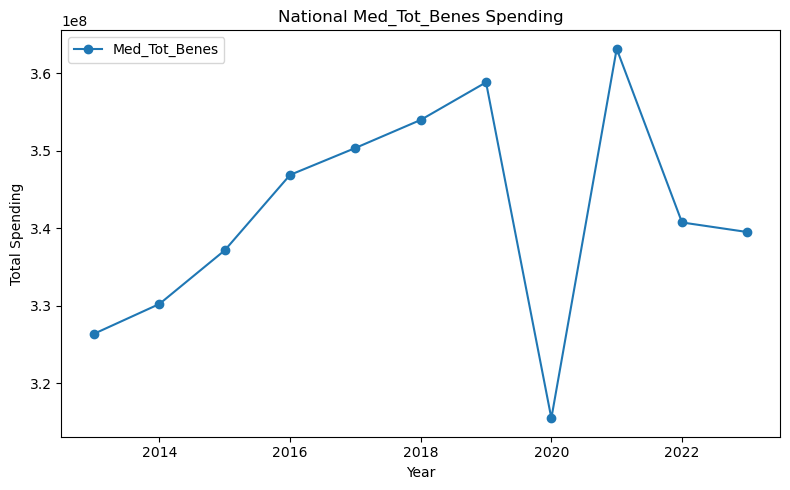

In [52]:
# Total number of med beneficiaries plot
plt_total_col_by_year(df,'Med_Tot_Benes')

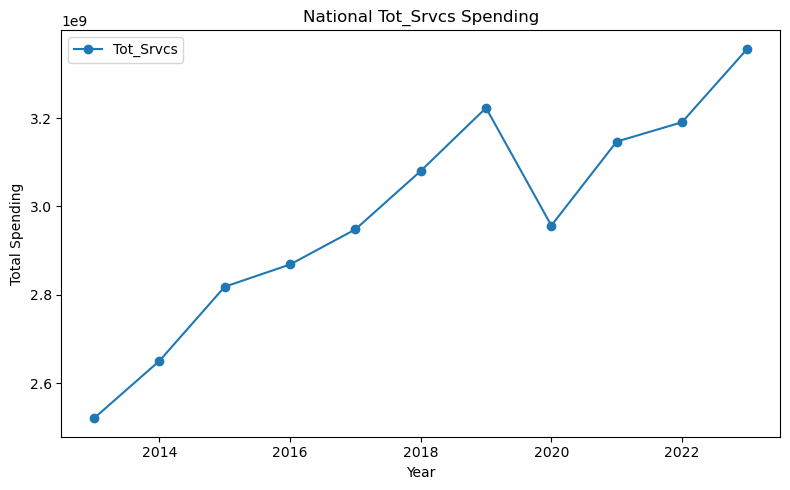

In [53]:
# total number of services plot
plt_total_col_by_year(df,'Tot_Srvcs')

## Behavioral Health columns

In [59]:
# extract BH columns
colsBH = [c for c in df.columns.tolist() if 'BH' in c]
dfBH = df[['Rndrng_NPI','Rndrng_Prvdr_Type','Tot_Benes','Tot_Mdcr_Pymt_Amt','year'] + colsBH]

# BH columns only exist in 2017-2023
mask17 = dfBH['year']>=2017
mask23 = dfBH['year']<=2023
dfBH1723 = dfBH[mask17&mask23].copy()

if dfBH1723['Tot_Mdcr_Pymt_Amt'].min() <= 0:
    m = sorted(dfBH1723['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x>0 else 0).unique())[1]

dfBH1723['Tot_Mdcr_Pymt_Amt'] = dfBH1723['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else m) # avoid -inf after taking log
dfBH1723['Log_Tot_Pymt'] = np.log(dfBH1723['Tot_Mdcr_Pymt_Amt'])

In [60]:
# check missing data percentage for each column in BH

def check_missing_data_percentage(df,cols):
    result = {}
    total_mask = np.array([True] * df.shape[0]) # initial booleans for each row, assuming all rows are not nan
    for col in cols:
        mask = ~df[col].isna() # if a row is nan, then F; if a row is not nan, then T
        total_mask = (total_mask & mask) # if a row is nan, the row turns F; if a row is not nan, the row remains F
        result[col] = df[mask].shape[0]/df.shape[0]
    result['Good_Data_Percent'] = sum(total_mask)/df.shape[0]
    return pd.DataFrame([result],index=['nan_percentage']), total_mask

check_missing_data_percentage(dfBH1723,colsBH)[0]

,Bene_CC_BH_ADHD_OthCD_V1_Pct,Bene_CC_BH_Alcohol_Drug_V1_Pct,Bene_CC_BH_Tobacco_V1_Pct,Bene_CC_BH_Alz_NonAlzdem_V2_Pct,Bene_CC_BH_Anxiety_V1_Pct,Bene_CC_BH_Bipolar_V1_Pct,Bene_CC_BH_Mood_V2_Pct,Bene_CC_BH_Depress_V1_Pct,Bene_CC_BH_PD_V1_Pct,Bene_CC_BH_PTSD_V1_Pct,Bene_CC_BH_Schizo_OthPsy_V1_Pct,Good_Data_Percent
nan_percentage,0.348503,0.561731,0.651809,0.596152,0.836407,0.465133,0.849555,0.825217,0.354317,0.341834,0.431905,0.067824


In [61]:
# get the number of benes on only the good data rows
mask = check_missing_data_percentage(dfBH1723,colsBH)[1]
dfNumberBene = pd.DataFrame()

for col in colsBH:
    dfNumberBene[f'{col[:-7]}'] = round(dfBH1723[mask][col] * dfBH1723[mask]['Tot_Benes']/100)
    dfNumberBene[f'{col[:-7]}'] = dfNumberBene.loc[:,f'{col[:-7]}'].apply(lambda x: x if x!=0 else 1) # if it's zero, we make it to be 1 since we will take log

dfNumberBene

,Bene_CC_BH_ADHD_OthCD,Bene_CC_BH_Alcohol_Drug,Bene_CC_BH_Tobacco,Bene_CC_BH_Alz_NonAlzdem,Bene_CC_BH_Anxiety,Bene_CC_BH_Bipolar,Bene_CC_BH_Mood,Bene_CC_BH_Depress,Bene_CC_BH_PD,Bene_CC_BH_PTSD,Bene_CC_BH_Schizo_OthPsy
4016244,1.0,37.0,74.0,185.0,407.0,37.0,518.0,407.0,37.0,1.0,37.0
4016278,42.0,76.0,127.0,144.0,296.0,118.0,330.0,279.0,34.0,25.0,68.0
4016281,26.0,385.0,513.0,257.0,872.0,103.0,795.0,744.0,51.0,51.0,103.0
4016290,26.0,184.0,276.0,237.0,487.0,118.0,526.0,474.0,53.0,26.0,66.0
4016291,42.0,254.0,339.0,212.0,805.0,170.0,805.0,721.0,85.0,42.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...
12232115,29.0,146.0,175.0,175.0,700.0,58.0,641.0,583.0,29.0,29.0,29.0
12232125,12.0,149.0,324.0,174.0,411.0,75.0,448.0,436.0,25.0,25.0,25.0
12232137,11.0,87.0,164.0,98.0,360.0,44.0,360.0,328.0,22.0,22.0,22.0
12232143,11.0,116.0,180.0,158.0,370.0,63.0,359.0,338.0,11.0,11.0,74.0


array([[<Axes: title={'center': 'Bene_CC_BH_ADHD_OthCD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Alcohol_Drug'}>,
        <Axes: title={'center': 'Bene_CC_BH_Tobacco'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Alz_NonAlzdem'}>,
        <Axes: title={'center': 'Bene_CC_BH_Anxiety'}>,
        <Axes: title={'center': 'Bene_CC_BH_Bipolar'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Mood'}>,
        <Axes: title={'center': 'Bene_CC_BH_Depress'}>,
        <Axes: title={'center': 'Bene_CC_BH_PD'}>],
       [<Axes: title={'center': 'Bene_CC_BH_PTSD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Schizo_OthPsy'}>, <Axes: >]],
      dtype=object)

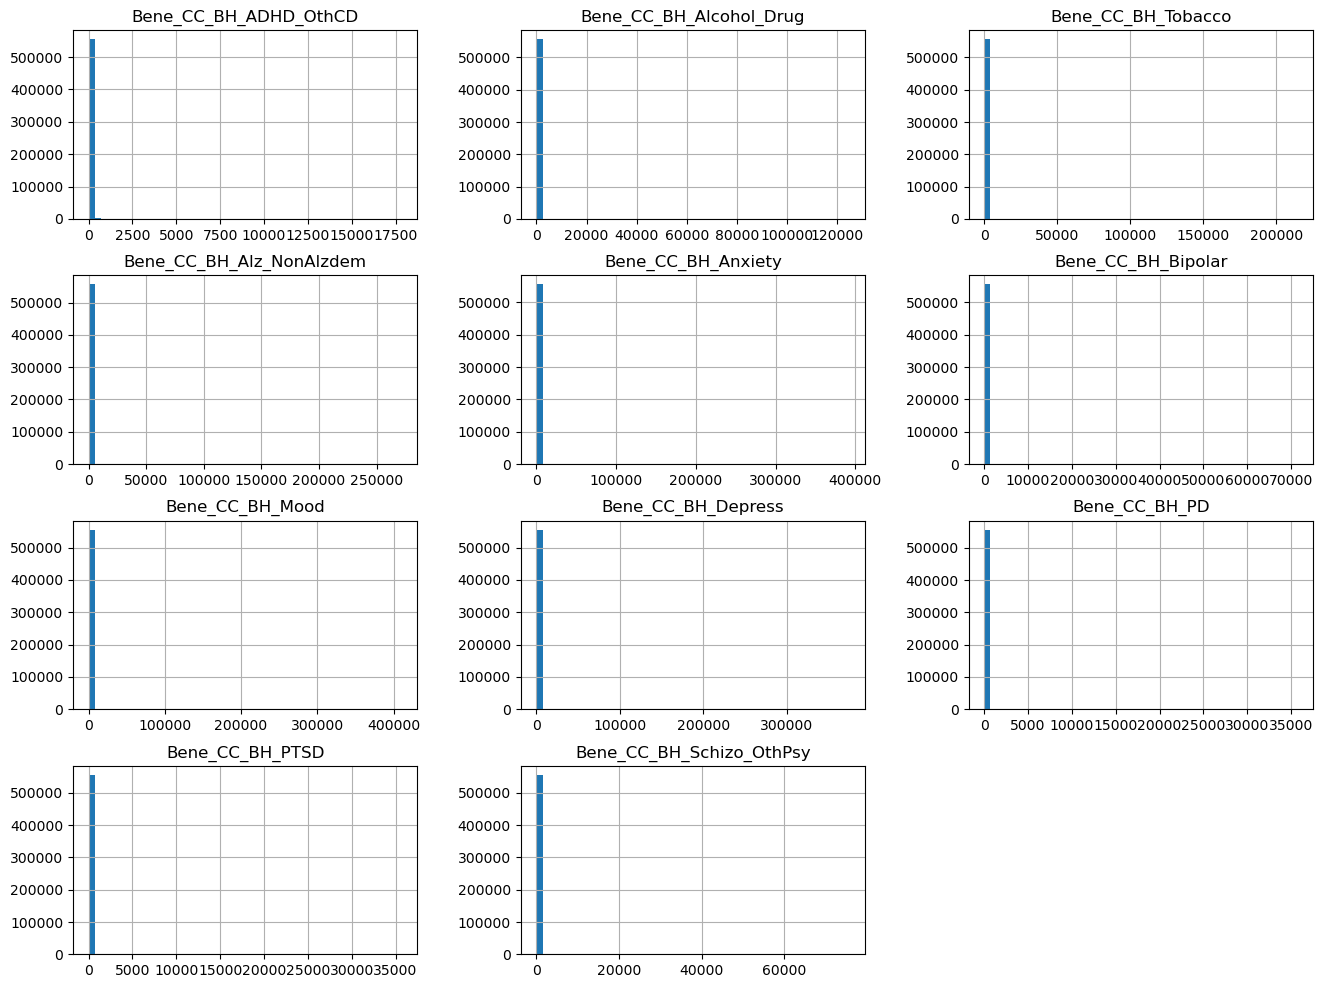

In [62]:
dfNumberBene.hist(figsize=(16,12), bins=50)

Not much going on. Now try to take log.

array([[<Axes: title={'center': 'Bene_CC_BH_ADHD_OthCD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Alcohol_Drug'}>,
        <Axes: title={'center': 'Bene_CC_BH_Tobacco'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Alz_NonAlzdem'}>,
        <Axes: title={'center': 'Bene_CC_BH_Anxiety'}>,
        <Axes: title={'center': 'Bene_CC_BH_Bipolar'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Mood'}>,
        <Axes: title={'center': 'Bene_CC_BH_Depress'}>,
        <Axes: title={'center': 'Bene_CC_BH_PD'}>],
       [<Axes: title={'center': 'Bene_CC_BH_PTSD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Schizo_OthPsy'}>, <Axes: >]],
      dtype=object)

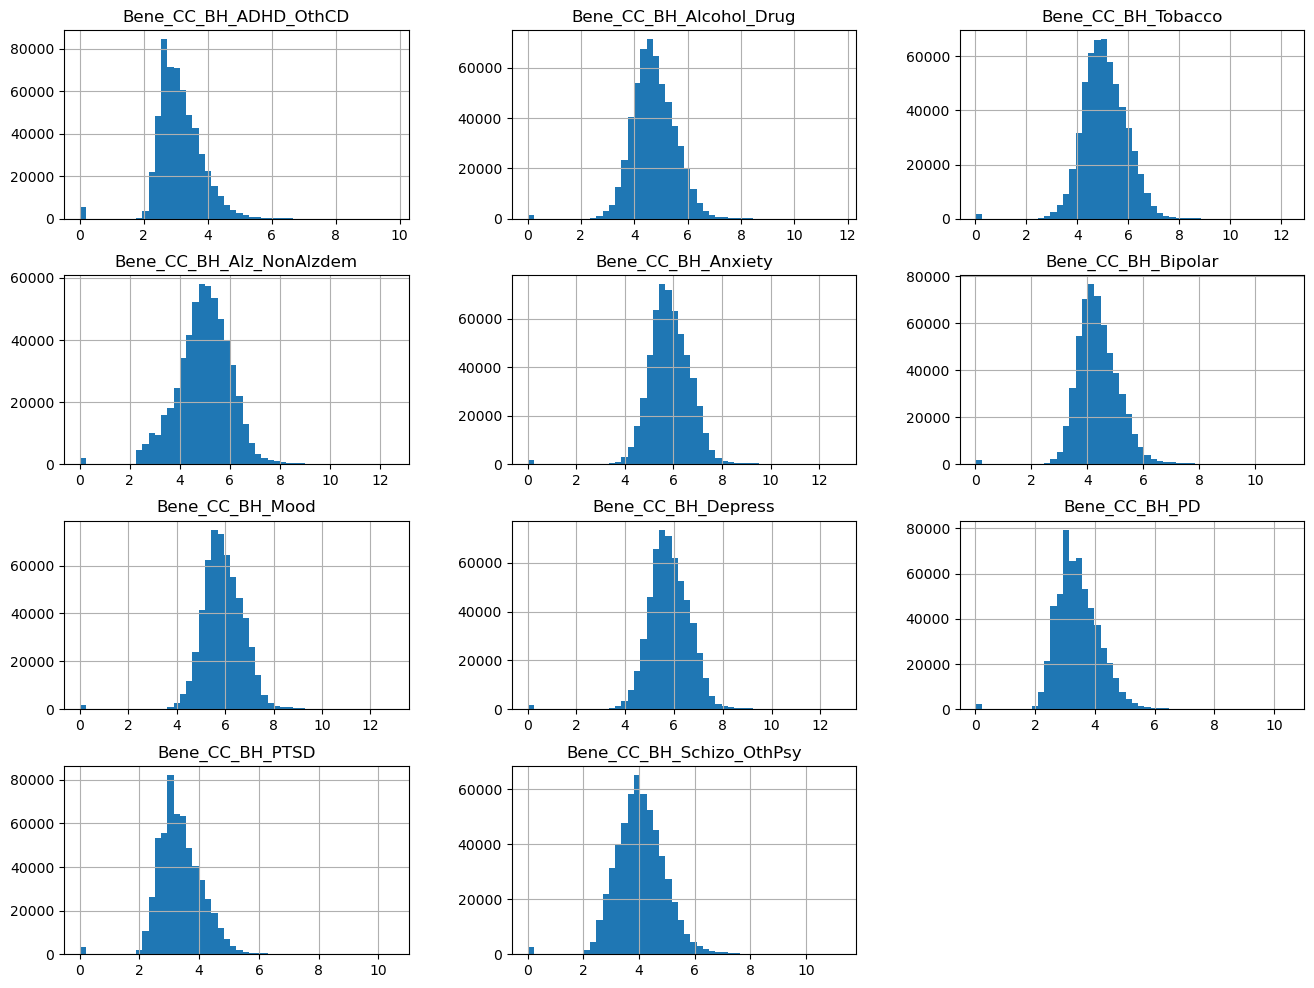

In [63]:
np.log(dfNumberBene).hist(figsize=(16,12), bins=50)

They are approximately appear to be in a bell shape.

### impute missing data with 5

In [ ]:
# assume 5 benes for missing percentage data

def impute_missing_data(df,cols):
    for col in cols:
        mask = df[col].isna()
        temp = df[mask]
        temp.loc[:,col] = round(5/temp.loc[:,'Tot_Benes']*100)
        df.loc[mask,col]=temp[col]
    return df

dfimputeBH = dfBH1723.copy()
dfimputeBH = impute_missing_data(dfimputeBH,colsBH)
dfimputeBH

,Rndrng_NPI,Rndrng_Prvdr_Type,Tot_Benes,Tot_Mdcr_Pymt_Amt,year,Bene_CC_BH_ADHD_OthCD_V1_Pct,Bene_CC_BH_Alcohol_Drug_V1_Pct,Bene_CC_BH_Tobacco_V1_Pct,Bene_CC_BH_Alz_NonAlzdem_V2_Pct,Bene_CC_BH_Anxiety_V1_Pct,Bene_CC_BH_Bipolar_V1_Pct,Bene_CC_BH_Mood_V2_Pct,Bene_CC_BH_Depress_V1_Pct,Bene_CC_BH_PD_V1_Pct,Bene_CC_BH_PTSD_V1_Pct,Bene_CC_BH_Schizo_OthPsy_V1_Pct,Log_Tot_Pymt
4016243,1003000126,InternalMedicine,578,137084.55,2017,1.0,10.0,21.0,25.0,42.0,7.0,45.0,43.0,3.0,3.0,8.0,11.828353
4016244,1003000134,Pathology,3703,243698.97,2017,0.0,1.0,2.0,5.0,11.0,1.0,14.0,11.0,1.0,0.0,1.0,12.403689
4016245,1003000142,Anesthesiology,278,119726.66,2017,2.0,18.0,28.0,2.0,41.0,10.0,47.0,43.0,2.0,2.0,4.0,11.692967
4016246,1003000407,FamilyPractice,260,66084.78,2017,2.0,7.0,12.0,42.0,45.0,13.0,53.0,49.0,7.0,2.0,13.0,11.098694
4016247,1003000423,Obstetrics&Gynecology,71,11244.68,2017,7.0,7.0,7.0,7.0,27.0,7.0,32.0,24.0,0.0,7.0,0.0,9.327650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12232189,1992999569,Optometry,16,1588.78,2023,31.0,31.0,31.0,31.0,31.0,31.0,31.0,31.0,0.0,0.0,31.0,7.370722
12232190,1992999775,AmbulatorySurgicalCenter,228,856134.21,2023,2.0,5.0,10.0,2.0,19.0,2.0,25.0,25.0,2.0,2.0,2.0,13.660182
12232191,1992999817,OrthopedicSurgery,18,5600.89,2023,0.0,28.0,28.0,0.0,28.0,28.0,28.0,28.0,0.0,0.0,0.0,8.630681
12232192,1992999825,Otolaryngology,405,69628.19,2023,1.0,4.0,3.0,7.0,19.0,1.0,19.0,17.0,1.0,3.0,1.0,11.150925


array([[<Axes: title={'center': 'Bene_CC_BH_ADHD_OthCD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Alcohol_Drug'}>,
        <Axes: title={'center': 'Bene_CC_BH_Tobacco'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Alz_NonAlzdem'}>,
        <Axes: title={'center': 'Bene_CC_BH_Anxiety'}>,
        <Axes: title={'center': 'Bene_CC_BH_Bipolar'}>],
       [<Axes: title={'center': 'Bene_CC_BH_Mood'}>,
        <Axes: title={'center': 'Bene_CC_BH_Depress'}>,
        <Axes: title={'center': 'Bene_CC_BH_PD'}>],
       [<Axes: title={'center': 'Bene_CC_BH_PTSD'}>,
        <Axes: title={'center': 'Bene_CC_BH_Schizo_OthPsy'}>, <Axes: >]],
      dtype=object)

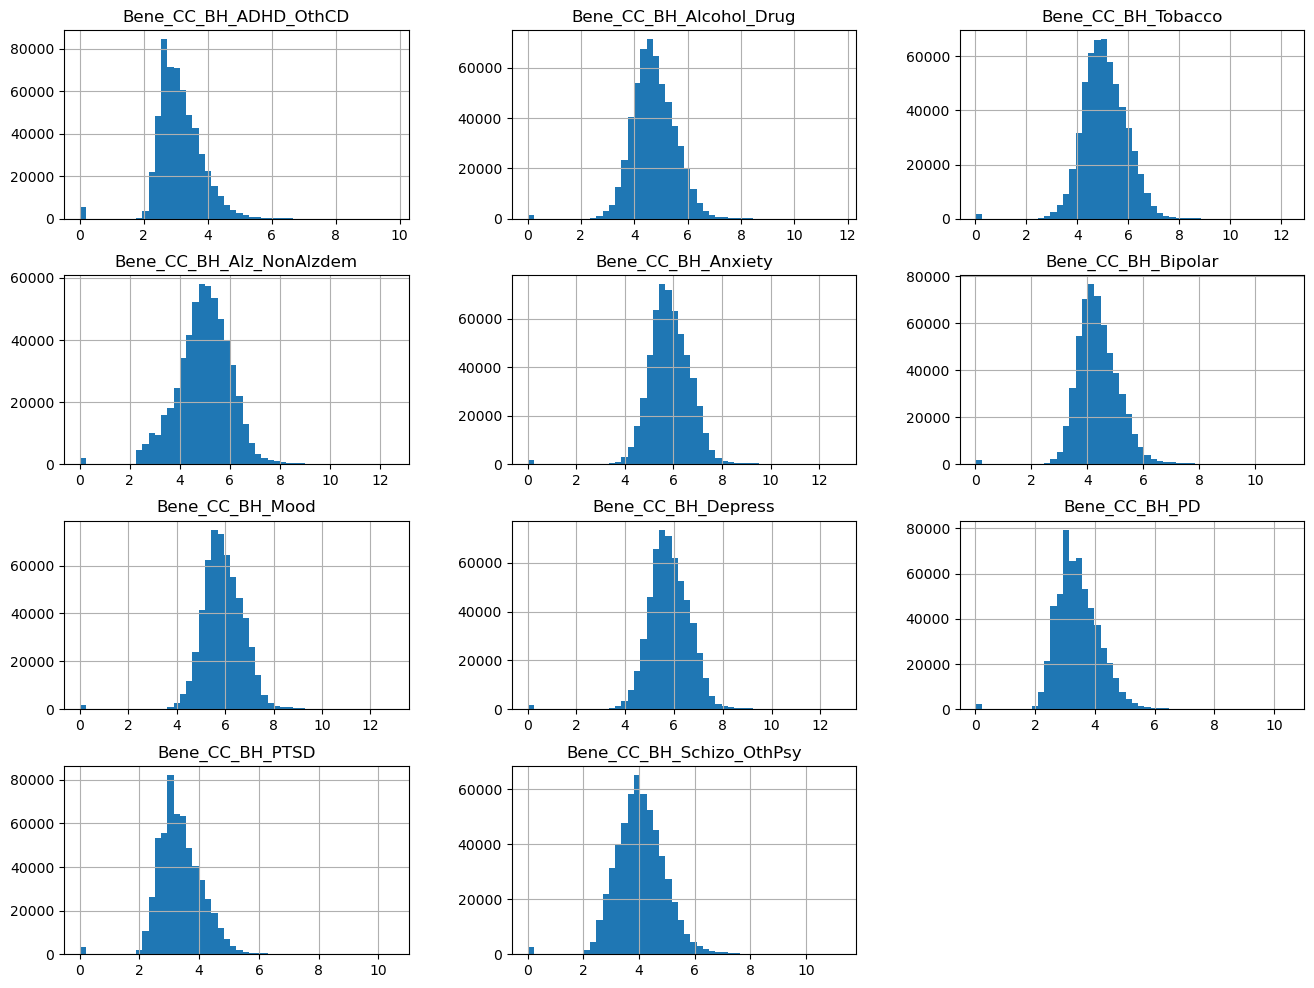

In [65]:
dfNumberBene = pd.DataFrame()

for col in colsBH:
    dfNumberBene[f'{col[:-7]}'] = round(dfimputeBH[mask][col] * dfimputeBH[mask]['Tot_Benes']/100)
    dfNumberBene[f'{col[:-7]}'] = dfNumberBene.loc[:,f'{col[:-7]}'].apply(lambda x: x if x!=0 else 1) # if it's zero, we make it to be 1 since we will take log

np.log(dfNumberBene).hist(figsize=(16,12), bins=50)

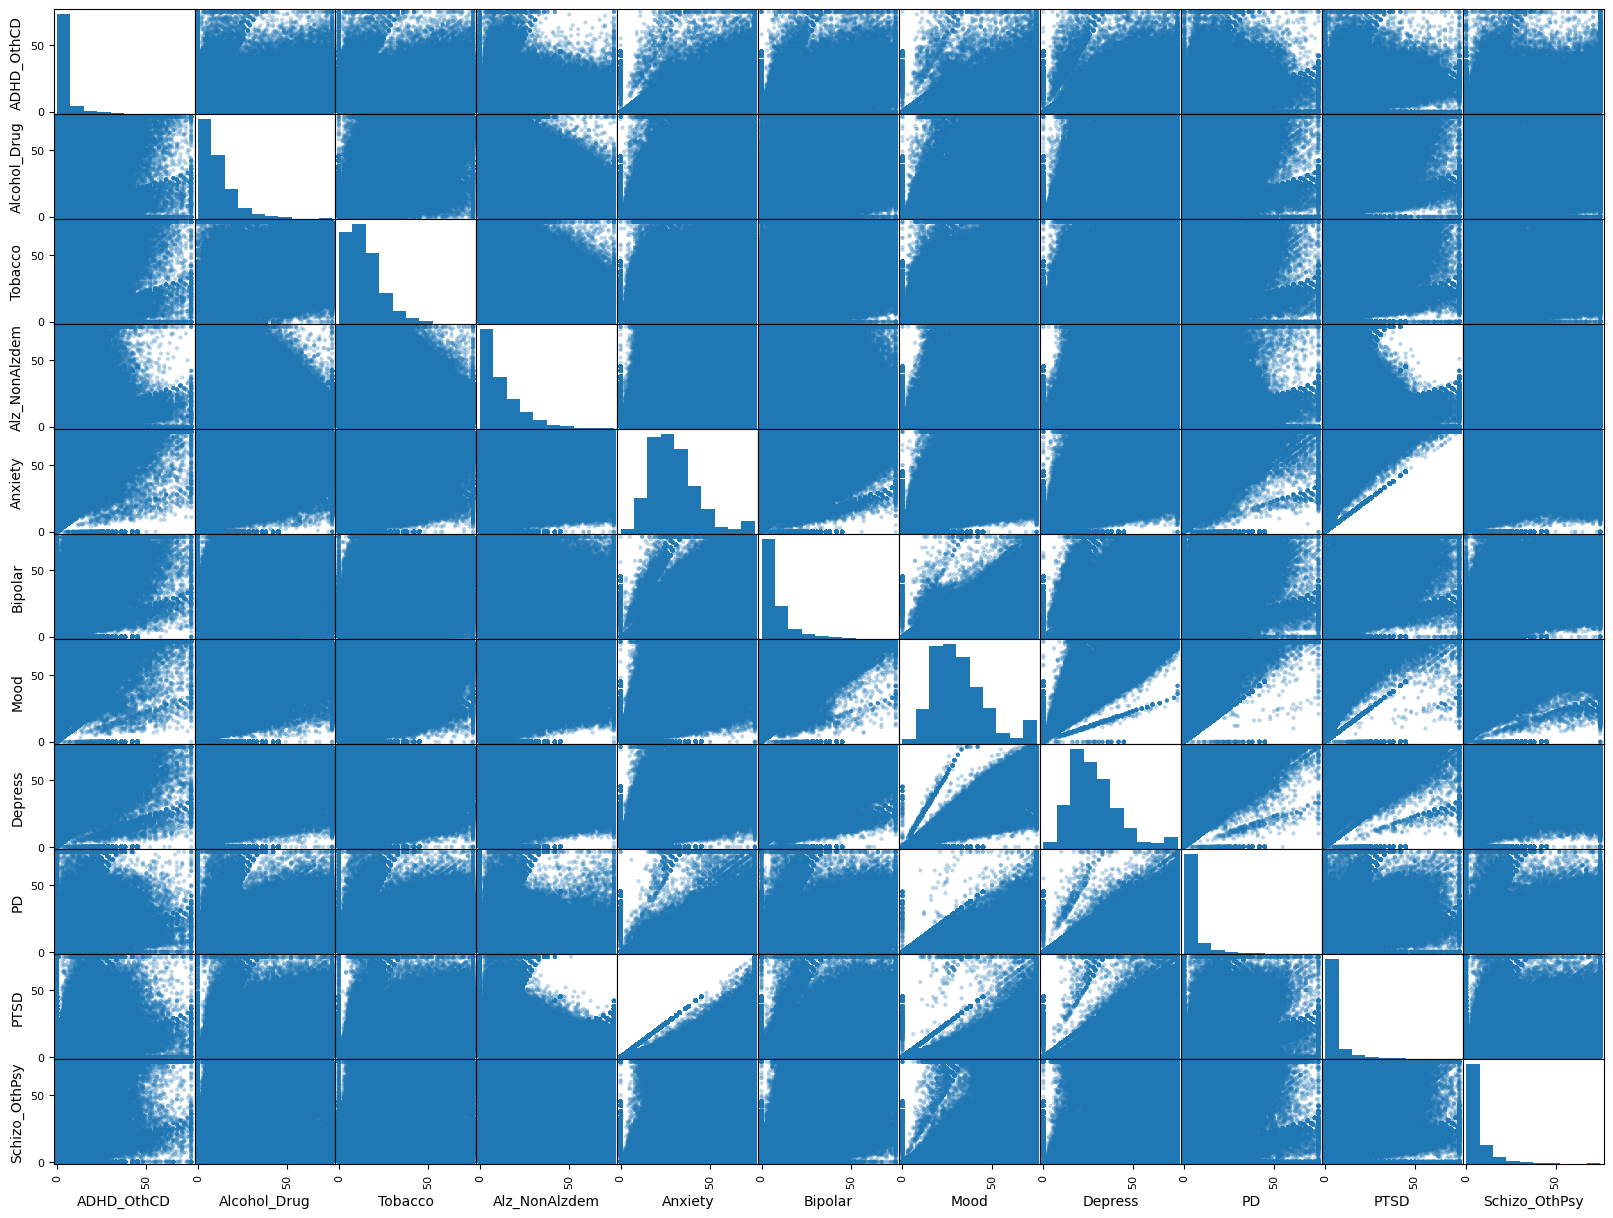

In [66]:
# get shorter column names for BH columns
colsBHnames = [x[11:-7] for x in colsBH]

pretty = {}

for i in range(len(colsBH)):
    pretty[colsBH[i]] = colsBHnames[i]

dftemp = dfimputeBH.rename(columns=pretty)

pd.plotting.scatter_matrix(dftemp[colsBHnames],figsize=(20,15),diagonal = 'hist',alpha=0.3)
plt.show()

### Correlation matrix between the BH and pymt

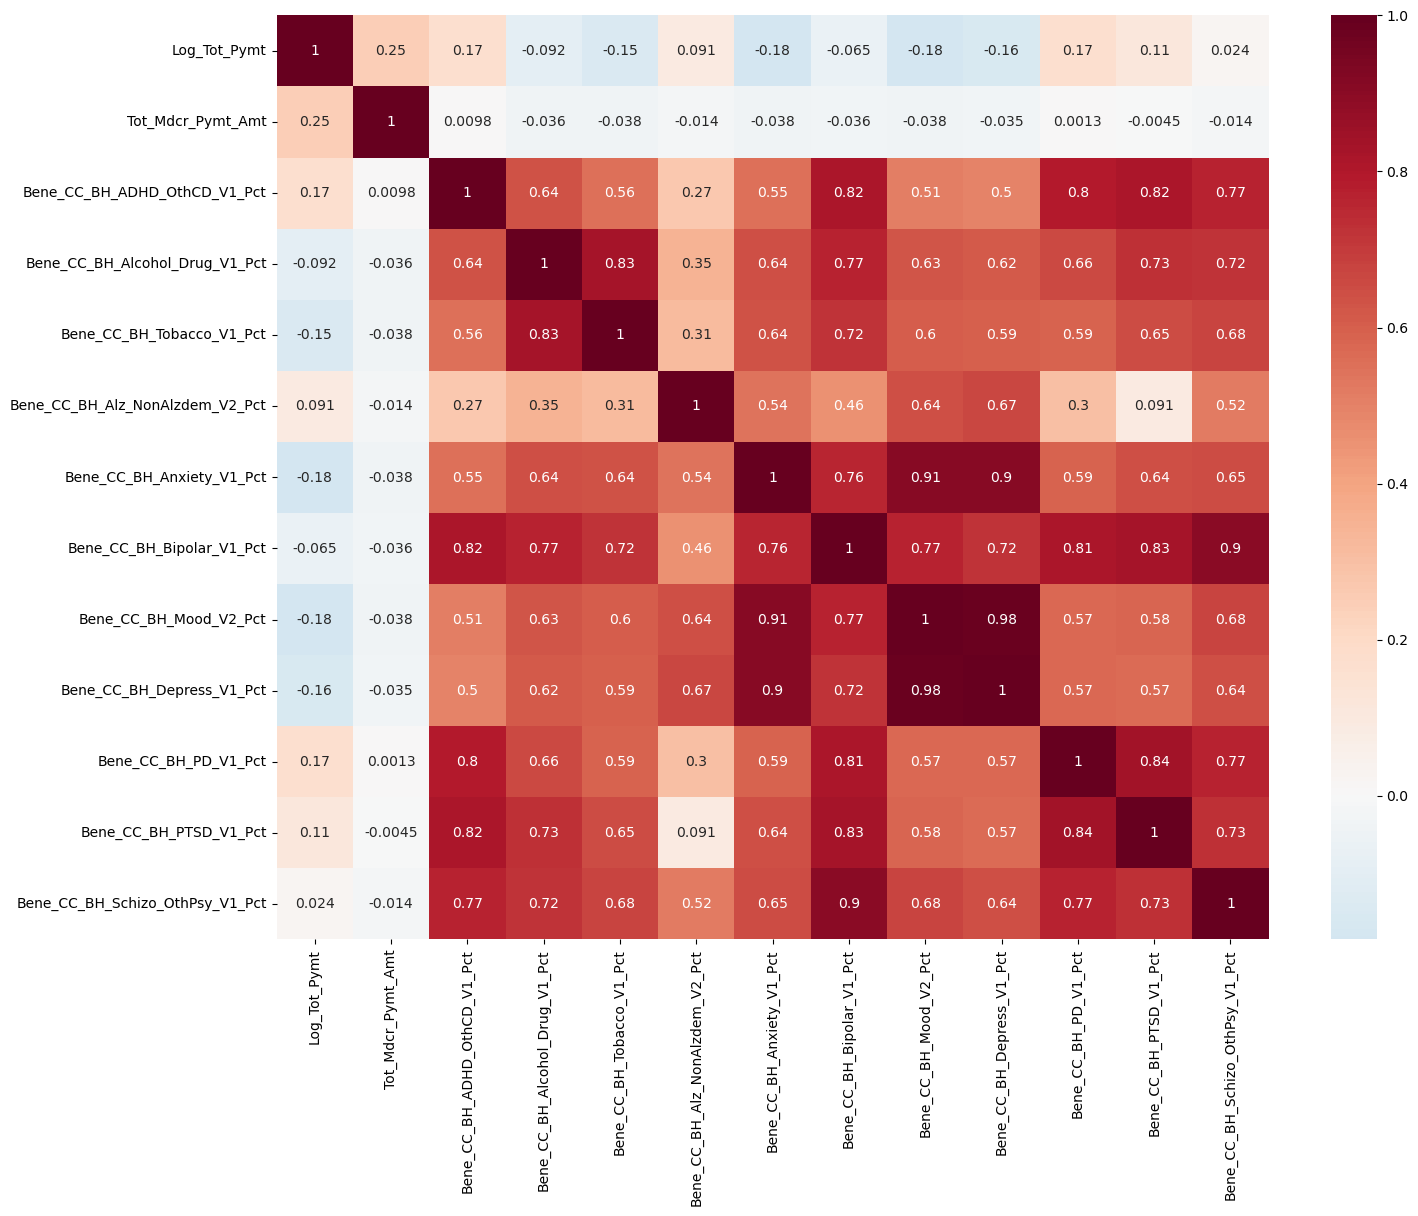

In [69]:
# correlation heatmap between Log_Pyt, Pyt and other columns

corr = dfBH1723[['Log_Tot_Pymt','Tot_Mdcr_Pymt_Amt']+colsBH].corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,cmap='RdBu_r',center=0)
plt.show()

### Histogram of each BH column

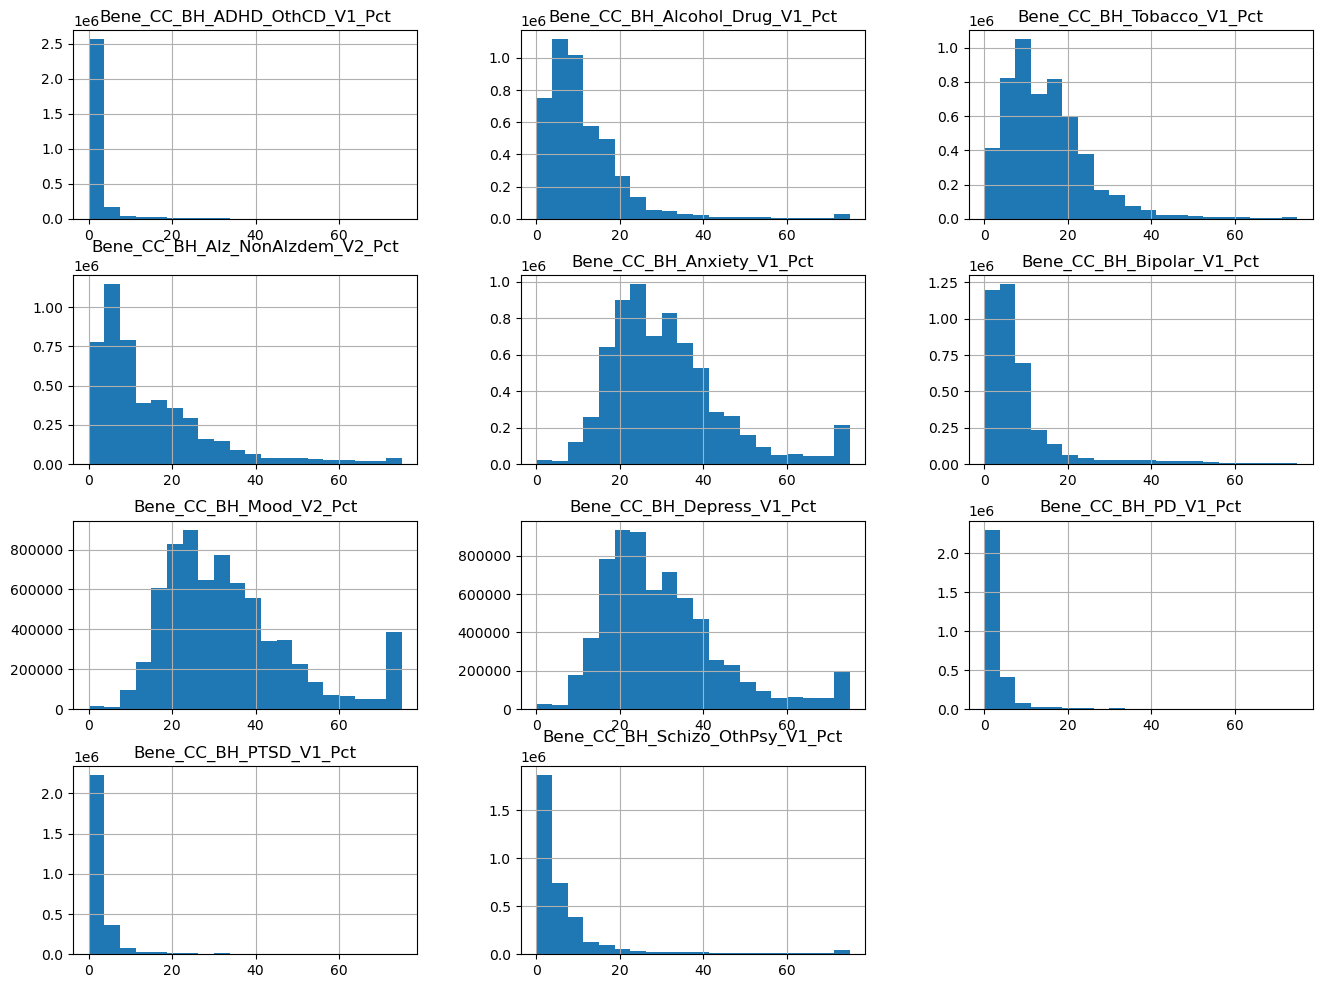

In [72]:
dfBH1723[colsBH].hist(figsize=(16,12),bins=20)
plt.show()

### Try a KMean clustering on BH columns

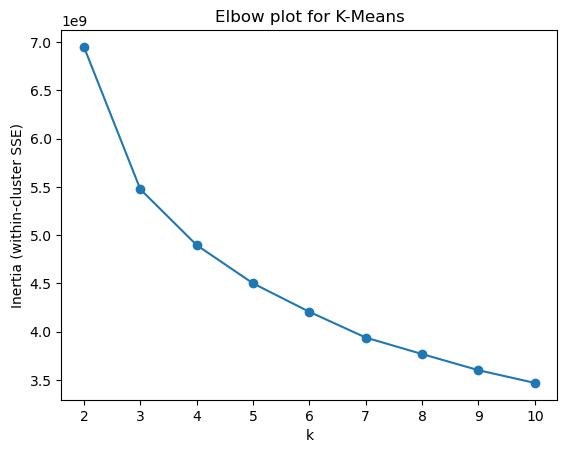

In [73]:
from sklearn.cluster import KMeans

Ks = range(2, 11)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(dfimputeBH[colsBH])
    inertias.append(km.inertia_) # km.insertia_ = within-cluster sum of squares

plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot for K-Means")
plt.show()

In [ ]:
#### Label data with KMean with k = 7 AND k = 5

In [74]:
k = 7
km = KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(dfimputeBH[colsBH])
label_7 = km.predict(dfimputeBH[colsBH])
dfimputeBH['BH_label_7'] = label_7

In [75]:
k = 5
km = KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(dfimputeBH[colsBH].fillna(0))
label_5 = km.predict(dfimputeBH[colsBH].fillna(0))
dfimputeBH['BH_label_5'] = label_5

/var/folders/46/mjvmwj6x7n5_cdghvmx10bkm0000gn/T/ipykernel_59976/2160202794.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=dfimputeBH[group].dropna().unique())


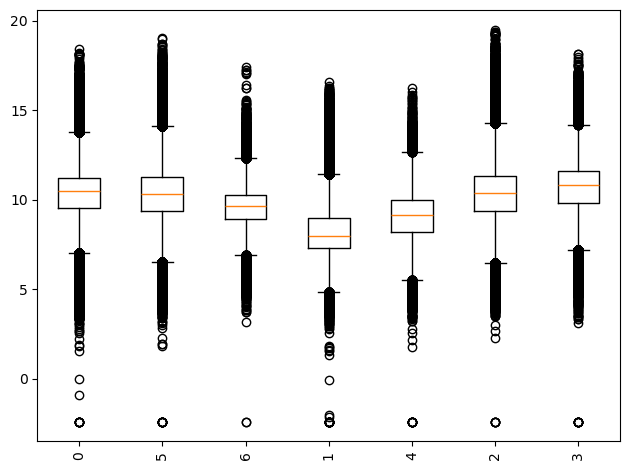

In [76]:
# boxplot for BH columns by cluster label (K=7)

y = "Log_Tot_Pymt"
group = "BH_label_7"

groups = [g[y].dropna().values for _, g in dfimputeBH.groupby(group)]

plt.boxplot(groups, labels=dfimputeBH[group].dropna().unique())
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/var/folders/46/mjvmwj6x7n5_cdghvmx10bkm0000gn/T/ipykernel_59976/956833722.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=dfimputeBH[group].dropna().unique())


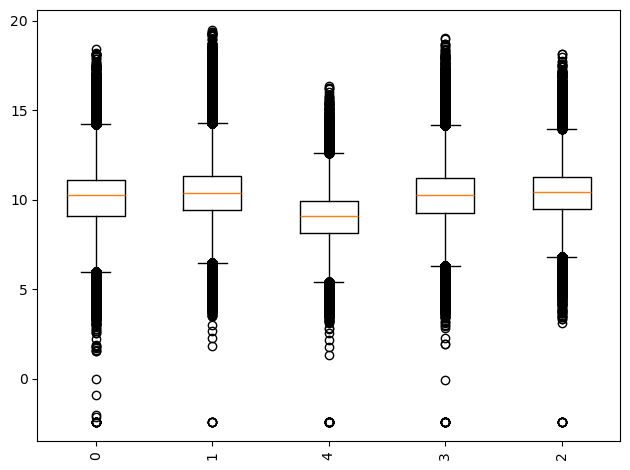

In [77]:
# boxplot for BH columns by cluster label (K=5)

y = "Log_Tot_Pymt"
group = "BH_label_5"

groups = [g[y].dropna().values for _, g in dfimputeBH.groupby(group)]

plt.boxplot(groups, labels=dfimputeBH[group].dropna().unique())
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()